<a href="https://colab.research.google.com/github/mmierzwa2002/SI_lab/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [70]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [71]:
def scale(image,label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [72]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [73]:
BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [74]:
input_size = 784
output_size = 10
hidden_layer_size = 50

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [75]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs = NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data = (validation_inputs, validation_targets),
          verbose = 1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8829 - loss: 0.4114 - val_accuracy: 0.9407 - val_loss: 0.2057
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9486 - loss: 0.1767 - val_accuracy: 0.9533 - val_loss: 0.1548
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9617 - loss: 0.1315 - val_accuracy: 0.9580 - val_loss: 0.1357
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9684 - loss: 0.1066 - val_accuracy: 0.9603 - val_loss: 0.1278
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9736 - loss: 0.0905 - val_accuracy: 0.9632 - val_loss: 0.1156
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9768 - loss: 0.0789 - val_accuracy: 0.9667 - val_loss: 0.1130
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9801 - loss: 0.0676 - val_accuracy: 0.9693 - val_loss: 0.1050
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9825 - loss: 0.0593 - val_accura

In [76]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9716 - loss: 0.1005
Test loss: 0.10. Test accuracy: 97.16%


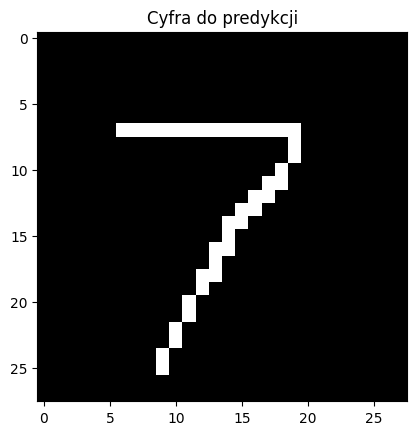

In [77]:
img_path = 'cyfra.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Cyfra do predykcji")
plt.show()

In [78]:
img_normalized = img / 255.0
img_ready = np.reshape(img_normalized, (1, 28, 28, 1))
prediction = model.predict(img_ready)
predicted_number = np.argmax(prediction)
print(f"Model rozpoznał cyfrę: {predicted_number}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Model rozpoznał cyfrę: 7
